# LLM Generativo Zephyr-7B

In [ ]:
# Librerías y Configuración
#!pip install accelerate bitsandbytes


In [ ]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed
from tqdm import tqdm
import numpy as np
import warnings
warnings.filterwarnings('ignore')
set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
quantization_config = BitsAndBytesConfig(load_in_4bit=False, load_in_8bit=True)
data_path = r"C:\Users\Sistemas\Desktop\beto solo grid\nuevo_df.csv"
df = pd.read_csv(data_path)

# Aseguramos que solo queden los 4 niveles esperados
NIVELES = ["Bajo", "Medio bajo", "Medio alto", "Alto"]
df = df[df["Nivel_f"].isin(NIVELES)].reset_index(drop=True)

# Split
df_train, df_test = train_test_split(
    df,
    test_size=0.10,
    random_state=42,
    stratify=df["Nivel_f"]
)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Tamaño entrenamiento:", len(df_train))
print("Tamaño prueba:", len(df_test))
print(df_train["Nivel_f"].value_counts())
print(df_test["Nivel_f"].value_counts())



c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tamaño entrenamiento: 1728
Tamaño prueba: 192
Nivel_f
Medio alto    618
Medio bajo    580
Bajo          279
Alto          251
Name: count, dtype: int64
Nivel_f
Medio alto    69
Medio bajo    64
Bajo          31
Alto          28
Name: count, dtype: int64


In [ ]:
# Ejemplos (reales) – 5 por clase
N_EJEMPLOS_POR_CLASE = 5
EJEMPLOS_SEED        = 42

def construir_ejemplos_reales(df_source, n_por_clase=N_EJEMPLOS_POR_CLASE, seed=EJEMPLOS_SEED):
    """
    Selecciona n_por_clase textos reales por etiqueta para usar
    como ejemplos few-shot en el prompt.
    """
    np.random.seed(seed)
    ejemplos = []
    for nivel in NIVELES:                         # ['Bajo', 'Medio bajo', …, 'Alto']
        textos = df_source[df_source["Nivel_f"] == nivel]["clean_text"].dropna()
        muestras = textos.sample(
            n=min(n_por_clase, len(textos)),
            random_state=seed
        ).tolist()
        ejemplos.extend(
            [{"texto": t.strip(), "nivel": nivel} for t in muestras]
        )
    return ejemplos

# Construye los ejemplos a partir del train split (df_train)
EJEMPLOS = construir_ejemplos_reales(df_train)



In [ ]:
import random

def construir_prompt(texto, shuffle=True):
    ejemplos = EJEMPLOS.copy()
    if shuffle:
        random.shuffle(ejemplos)
    prompt = (
        "Evalúa el siguiente texto académico y clasifícalo SOLO con una de estas categorías: Alto, Medio alto, Medio bajo, Bajo.\n"
        "Considera: argumentación, evidencias, conclusión, registro académico y ortografía.\n"
        "Escribe únicamente la etiqueta final en la última línea.\n"
        "Ejemplos:\n"
    )
    for ej in ejemplos:
        prompt += f"Texto: {ej['texto']}\nEtiqueta: {ej['nivel']}\n\n"
    prompt += f"Texto a evaluar: {texto}\nEtiqueta:"
    return prompt

# Carga del modelo y tokenizer
model = AutoModelForCausalLM.from_pretrained("HuggingFaceH4/zephyr-7b-alpha", torch_dtype=torch.float16, device_map="auto", quantization_config=quantization_config)
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceH4/zephyr-7b-alpha", padding_side="left")
tokenizer.pad_token = tokenizer.eos_token



Loading checkpoint shards: 100%|██████████| 8/8 [00:16<00:00,  2.00s/it]


In [ ]:
# Extracción robusta de la etiqueta
NIVELES = ["Alto", "Medio alto", "Medio bajo", "Bajo"]

LABEL_MAP = {
    'alto': 'Alto',
    'medio alto': 'Medio alto',
    'medioalto': 'Medio alto',
    'medio bajo': 'Medio bajo',
    'mediobajo': 'Medio bajo',
    'bajo': 'Bajo'
}

def limpiar_etiqueta(etiqueta):
    if pd.isnull(etiqueta):
        return "Indeterminado"
    e = etiqueta.strip().lower()
    return LABEL_MAP.get(e, "Indeterminado")

import re

def extract_last_label(response_text):
    pattern = r"\b(Alto|Medio alto|Medio bajo|Bajo)\b"
    matches = re.findall(pattern, response_text, flags=re.IGNORECASE)
    if matches:
        return limpiar_etiqueta(matches[-1])
    return "Indeterminado"

# Predicción con prompt few-shot
def classify_academic_llm_ensemble(texto, n=3):
    preds = []
    for _ in range(n):
        prompt = construir_prompt(texto, shuffle=True)
        messages = [
            {"role": "system", "content": "Eres un evaluador académico. Solo responde con la etiqueta en la última línea (Alto, Medio alto, Medio bajo, Bajo)."},
            {"role": "user", "content": prompt}
        ]
        inputs = tokenizer.apply_chat_template(
            messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
        ).to(device)
        generated_ids = model.generate(
            inputs,
            do_sample=False,
            max_new_tokens=2,
            repetition_penalty=1.1,
            num_beams=1
        )
        outputs = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        response_text = outputs[0].strip()
        preds.append(extract_last_label(response_text))
    # Voto mayoritario
    return pd.Series(preds).mode()[0]



In [ ]:
# Predicción en el set de prueba
tqdm.pandas()
df_test["Nivel_pred_llm"] = df_test["clean_text"].progress_apply(classify_academic_llm_ensemble)

df_test['Nivel_pred_llm'] = df_test['Nivel_pred_llm'].apply(limpiar_etiqueta)
df_test['Nivel_f'] = df_test['Nivel_f'].apply(limpiar_etiqueta)


  0%|          | 0/192 [00:00<?, ?it/s]The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for ope

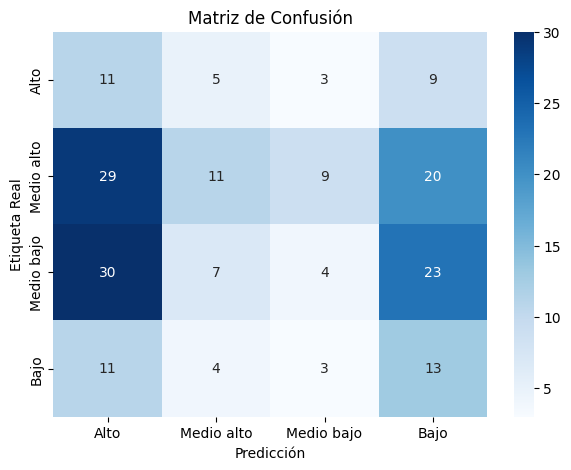

Reporte de Clasificación:
              precision    recall  f1-score   support

        Alto       0.14      0.39      0.20        28
        Bajo       0.20      0.42      0.27        31
  Medio alto       0.41      0.16      0.23        69
  Medio bajo       0.21      0.06      0.10        64

    accuracy                           0.20       192
   macro avg       0.24      0.26      0.20       192
weighted avg       0.27      0.20      0.19       192

Precisión Global: 0.20


In [ ]:
# Evaluación y métricas
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

true_labels = df_test["Nivel_f"]
pred_labels = df_test["Nivel_pred_llm"]

cm = confusion_matrix(true_labels, pred_labels, labels=NIVELES)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=NIVELES, yticklabels=NIVELES)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.title("Matriz de Confusión")
plt.show()

print("Reporte de Clasificación:")
print(classification_report(true_labels, pred_labels))
print(f"Precisión Global: {accuracy_score(true_labels, pred_labels):.2f}")



In [9]:
print(df_test['Nivel_pred_llm'].value_counts())


Nivel_pred_llm
Alto          81
Bajo          65
Medio alto    27
Medio bajo    19
Name: count, dtype: int64


In [ ]:
# Muestra resultados por clase (debug)
for nivel in NIVELES:
    print(f"\nEjemplo real de la clase '{nivel}':")
    print(df_test[df_test["Nivel_f"] == nivel][["clean_text", "Nivel_pred_llm"]].head(1).to_string(index=False))



Ejemplo real de la clase 'Alto':
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      